In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define the autoencoder model with 1D Convolutional layers
input_dim = X_scaled.shape[1]
latent_dim = 64

input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

autoencoder = Model(input_layer, decoder_layer5)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the data
autoencoder.fit(X_scaled, X_scaled,
                epochs=50,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping])

Epoch 1/50
986/986 [==============================] - 89s 78ms/step - loss: 0.0082 - val_loss: 2.2833e-04
Epoch 2/50
986/986 [==============================] - 86s 87ms/step - loss: 1.4600e-04 - val_loss: 9.7277e-05
Epoch 3/50
986/986 [==============================] - 68s 69ms/step - loss: 8.2364e-05 - val_loss: 6.5578e-05
Epoch 4/50
986/986 [==============================] - 74s 75ms/step - loss: 6.1056e-05 - val_loss: 5.2425e-05
Epoch 5/50
986/986 [==============================] - 77s 78ms/step - loss: 5.0788e-05 - val_loss: 4.4105e-05
Epoch 6/50
986/986 [==============================] - 71s 72ms/step - loss: 4.3228e-05 - val_loss: 4.2558e-05
Epoch 7/50
986/986 [==============================] - 63s 64ms/step - loss: 3.8737e-05 - val_loss: 3.5081e-05
Epoch 8/50
986/986 [==============================] - 75s 76ms/step - loss: 3.5765e-05 - val_loss: 3.2309e-05
Epoch 9/50
986/986 [==============================] - 75s 77ms/step - loss: 3.3255e-05 - val_loss: 3.4358e-05
Epoch 10/50
98

1095/1095 [==============================] - 37s 33ms/step
Model saved at: trained_1D_autoencoder_model.h5
Threshold saved at: trained_1D_threshold.npy


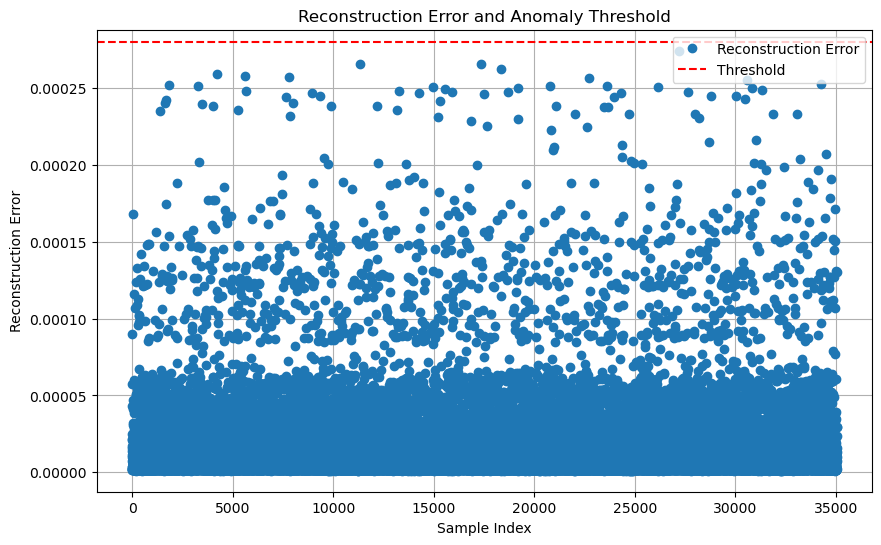

In [6]:
# Calculate reconstruction error
train_predictions = autoencoder.predict(X_scaled)
# reconstruction_error = np.mean(np.square(X_scaled - train_predictions), axis=1)
#################################################################################
# Calculate reconstruction error
reshaped_train_predictions = train_predictions.reshape(X_scaled.shape)  # Reshape to match original input shape
reconstruction_error = np.mean(np.square(X_scaled - reshaped_train_predictions), axis=1)
################################################################################

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (62 * mad)

# Print and save the trained autoencoder model
model_path = "trained_1D_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_1D_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold')
plt.legend()
plt.grid()
plt.show()


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
# y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


10/10 [==============================] - 1s 22ms/step
Threshold saved at: 0.00027998133676901713
Anomalous Data Indices:
[ 19  30  42  57  73  77  81  86  95 120 137 150 151 155 159 174 184 193
 228 252 256 260 266 269]


Accuracy: 0.5448275862068965
Precision: 0.75
Recall: 0.125
TNR: 0.958904109589041
FPR: 0.0410958904109589
FNR: 0.875
F1 Score: 0.21428571428571427
ROC AUC: 0.6726122526636226


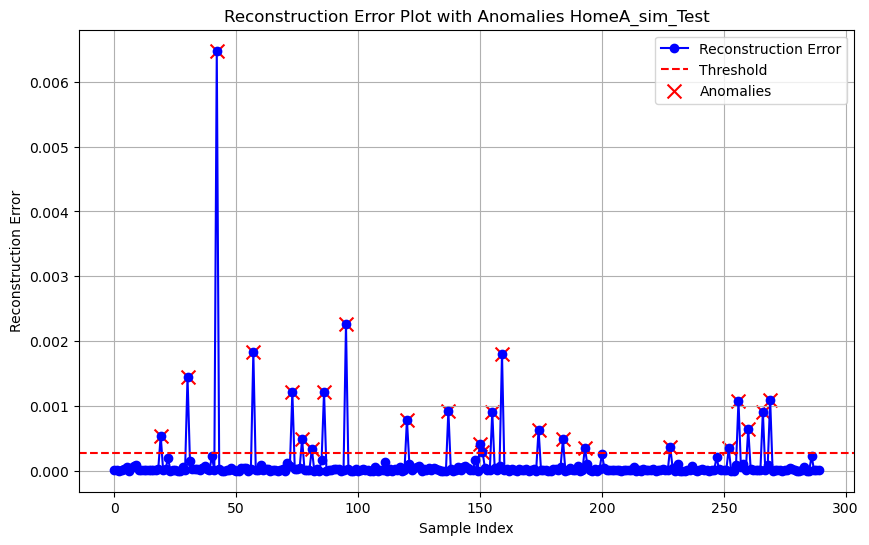

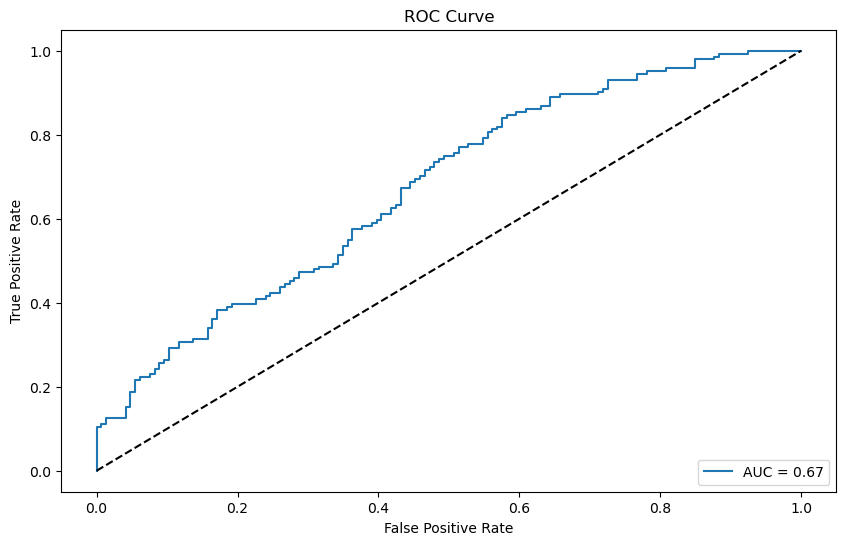

In [8]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)



548/548 [==============================] - 13s 23ms/step
Threshold saved at: 0.00027998133676901713
Anomalous Data Indices:
[   75   115   170   245   306   444   450   570   584   644   658   770
   780   881   934  1148  1204  1310  1446  1461  1544  1643  1711  1792
  1845  1878  1920  1971  2055  2096  2235  2305  2309  2349  2608  2650
  2754  2777  2897  2959  3072  3111  3135  3250  3351  3380  3443  3449
  3716  3772  3995  4024  4087  4144  4182  4229  4256  4322  4323  4328
  4367  4396  4429  4598  4605  4931  4953  5034  5114  5130  5133  5175
  5402  5539  5583  5668  5713  5785  5791  5898  5940  6082  6202  6209
  6392  6421  6575  6658  6767  6839  6865  6879  6921  6970  6978  7008
  7178  7179  7296  7355  7437  7514  7534  7551  7610  7613  7682  7787
  7858  7878  7933  7947  7951  8028  8052  8063  8084  8146  8323  8388
  8533  8576  8583  8616  8627  8637  8751  8808  8855  8885  8962  8994
  9001  9052  9157  9162  9238  9326  9370  9445  9511  9517  9519  9566


Accuracy: 0.502568493150685
Precision: 0.5862068965517241
Recall: 0.017465753424657535
TNR: 0.9876712328767123
FPR: 0.012328767123287671
FNR: 0.9825342465753425
F1 Score: 0.033920851346857336
ROC AUC: 0.6119396228185401


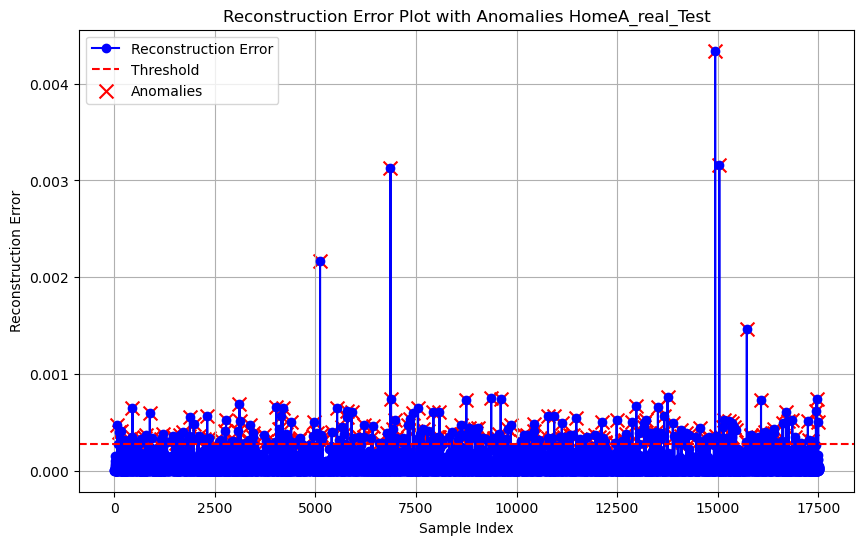

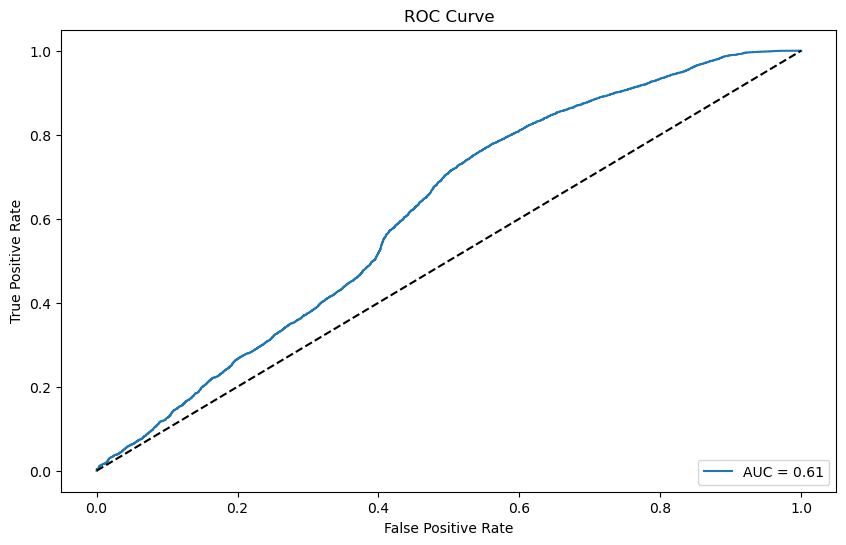

In [10]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


548/548 [==============================] - 15s 28ms/step
Threshold for Simulated Data saved at: 0.00027998133676901713
Threshold for Real Data saved at: 0.00027998133676901713


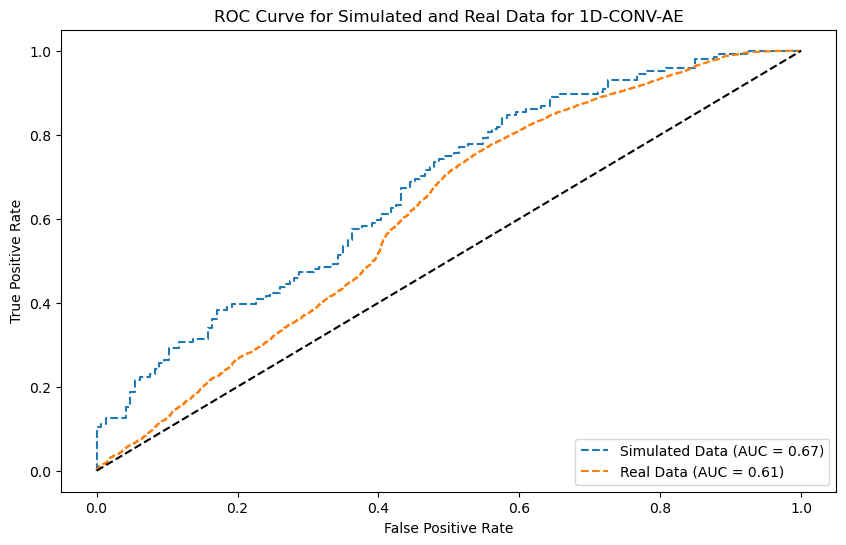

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train_sim = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test_sim = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
data_path_train_real = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test_real = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data for simulated and real data
train_data_sim = pd.read_csv(data_path_train_sim)
test_data_sim = pd.read_csv(data_path_test_sim)
train_data_real = pd.read_csv(data_path_train_real)
test_data_real = pd.read_csv(data_path_test_real)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train_sim = train_data_sim.drop(columns=['Label']).values
X_test_sim = test_data_sim.drop(columns=['Label']).values
y_test_sim = test_data_sim['Label'].values

X_train_real = train_data_real.drop(columns=['Label']).values
X_test_real = test_data_real.drop(columns=['Label']).values
y_test_real = test_data_real['Label'].values

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled_sim = scaler.fit_transform(X_train_sim)
X_test_scaled_sim = scaler.transform(X_test_sim)

X_train_scaled_real = scaler.fit_transform(X_train_real)
X_test_scaled_real = scaler.transform(X_test_real)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for both simulated and real test data
test_predictions_sim = autoencoder.predict(X_test_scaled_sim)
test_predictions_real = autoencoder.predict(X_test_scaled_real)

# Remove the extra channel dimension from test_predictions
test_predictions_sim = np.squeeze(test_predictions_sim, axis=-1)
test_predictions_real = np.squeeze(test_predictions_real, axis=-1)

test_reconstruction_error_sim = np.mean(np.square(X_test_scaled_sim - test_predictions_sim), axis=1)
test_reconstruction_error_real = np.mean(np.square(X_test_scaled_real - test_predictions_real), axis=1)

# Load the saved threshold
threshold_sim = np.load("trained_1D_threshold.npy")
threshold_real = np.load("trained_1D_threshold.npy")
print("Threshold for Simulated Data saved at:", threshold_sim)
print("Threshold for Real Data saved at:", threshold_real)

# Classify anomalies based on the threshold for both simulated and real data
anomalies_sim = test_reconstruction_error_sim > threshold_sim
anomalies_real = test_reconstruction_error_real > threshold_real

# Calculate ROC AUC for both simulated and real data
roc_auc_sim = roc_auc_score(y_test_sim, test_reconstruction_error_sim)
roc_auc_real = roc_auc_score(y_test_real, test_reconstruction_error_real)

# Compute ROC curves for both simulated and real data
fpr_curve_sim, tpr_curve_sim, _ = roc_curve(y_test_sim, test_reconstruction_error_sim)
fpr_curve_real, tpr_curve_real, _ = roc_curve(y_test_real, test_reconstruction_error_real)

# Plot ROC curves for both datasets on the same plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve_sim, tpr_curve_sim, label=f'Simulated Data (AUC = {roc_auc_sim:.2f})', linestyle='--')
plt.plot(fpr_curve_real, tpr_curve_real, label=f'Real Data (AUC = {roc_auc_real:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Simulated and Real Data for 1D-CONV-AE')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\1D-CONV-AE_roc_sim_real_1.png', bbox_inches='tight')
plt.show()


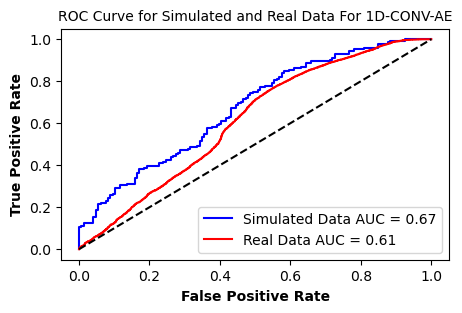

In [12]:
# Compute ROC curve and AUC for both datasets
fpr_curve_sim, tpr_curve_sim, _ = roc_curve(y_test_sim, test_reconstruction_error_sim)
roc_auc_sim = roc_auc_score(y_test_sim, test_reconstruction_error_sim)

fpr_curve_real, tpr_curve_real, _ = roc_curve(y_test_real, test_reconstruction_error_real)
roc_auc_real = roc_auc_score(y_test_real, test_reconstruction_error_real)

# Plot ROC curves for both datasets on the same plot
plt.figure(figsize=(5, 3))
plt.plot(fpr_curve_sim, tpr_curve_sim, label=f'Simulated Data AUC = {roc_auc_sim:.2f}', color='b')
plt.plot(fpr_curve_real, tpr_curve_real, label=f'Real Data AUC = {roc_auc_real:.2f}', color='r')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('ROC Curve for Simulated and Real Data For 1D-CONV-AE', fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\1D-CONV-AE_roc_sim_real.png', bbox_inches='tight')
plt.show()
####################################################################
# Plot ROC curves for both datasets on the same plot
# plt.figure(figsize=(5, 3))
# plt.plot(fpr_curve_sim, tpr_curve_sim, label=f'Simulated Data AUC = {roc_auc_sim:.2f}', color='b')
# plt.plot(fpr_curve_real, tpr_curve_real, label=f'Real Data AUC = {roc_auc_real:.2f}', color='r')
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
# plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
# plt.title('ROC Curve for Simulated and Real Data For MLP-AE', fontsize=10)
# plt.legend(loc='lower right', fontsize=10)
# plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\MLP-AE_roc_sim_real.png', bbox_inches='tight')
# plt.show()


###################################################################


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define the 1D Convolutional Autoencoder model with downsampling
input_dim = X_scaled.shape[1]
encoding_dim = 64

input_layer = Input(shape=(input_dim, 1))  # Adding a channel dimension for Conv1D
encoder_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
encoder_layer2 = MaxPooling1D(pool_size=2)(encoder_layer1)
encoder_layer3 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer2)
encoder_layer4 = MaxPooling1D(pool_size=2)(encoder_layer3)

decoder_layer1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(encoder_layer4)
decoder_layer2 = UpSampling1D(size=2)(decoder_layer1)
decoder_layer3 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(decoder_layer2)
decoder_layer4 = UpSampling1D(size=2)(decoder_layer3)
decoder_layer5 = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(decoder_layer4)

autoencoder = Model(input_layer, decoder_layer5)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_scaled, X_scaled,
                epochs=50,
                batch_size=64,
                shuffle=True,
                validation_split=0.1,
                callbacks=[early_stopping])


Epoch 1/50
493/493 [==============================] - 55s 93ms/step - loss: 0.0175 - val_loss: 7.5865e-04
Epoch 2/50
493/493 [==============================] - 48s 97ms/step - loss: 5.3142e-04 - val_loss: 4.4549e-04
Epoch 3/50
493/493 [==============================] - 48s 98ms/step - loss: 3.6210e-04 - val_loss: 2.5305e-04
Epoch 4/50
493/493 [==============================] - 47s 94ms/step - loss: 1.7348e-04 - val_loss: 1.2053e-04
Epoch 5/50
493/493 [==============================] - 47s 96ms/step - loss: 1.0782e-04 - val_loss: 9.6495e-05
Epoch 6/50
493/493 [==============================] - 46s 94ms/step - loss: 8.6364e-05 - val_loss: 7.6727e-05
Epoch 7/50
493/493 [==============================] - 46s 94ms/step - loss: 7.8040e-05 - val_loss: 6.8048e-05
Epoch 8/50
493/493 [==============================] - 46s 93ms/step - loss: 6.9131e-05 - val_loss: 6.5660e-05
Epoch 9/50
493/493 [==============================] - 47s 95ms/step - loss: 6.2607e-05 - val_loss: 6.6168e-05
Epoch 10/50
49

ValueError: operands could not be broadcast together with shapes (35040,1380) (35040,1380,1) 

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1380, 1)]         0         
                                                                 
 conv1d_5 (Conv1D)           (None, 1380, 32)          128       
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 690, 32)          0         
 1D)                                                             
                                                                 
 conv1d_6 (Conv1D)           (None, 690, 64)           6208      
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 345, 64)          0         
 1D)                                                             
                                                                 
 conv1d_7 (Conv1D)           (None, 345, 64)           1235

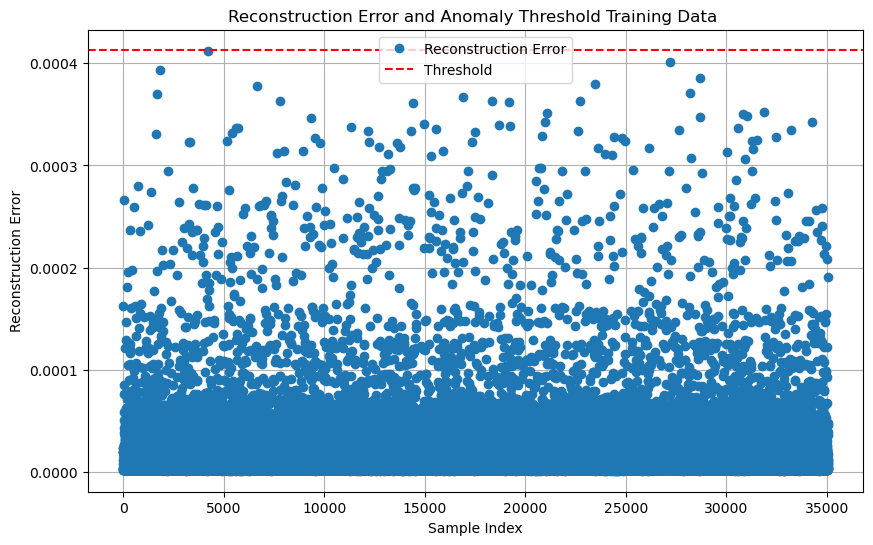

In [20]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for training data
# train_predictions = autoencoder.predict(X_scaled)
# reconstruction_error = np.mean(np.square(X_scaled - train_predictions), axis=1)

reshaped_train_predictions = train_predictions.reshape(X_scaled.shape)  # Reshape to match original input shape
reconstruction_error = np.mean(np.square(X_scaled - reshaped_train_predictions), axis=1)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (71 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_1D-autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_1D-threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Training Data ')
plt.legend()
plt.grid()
plt.show()

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_1D_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
# Remove the extra channel dimension from test_predictions
test_predictions = np.squeeze(test_predictions, axis=-1)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

###########################################################

# Load the saved threshold
threshold = np.load("trained_1D_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

C:\Users\olufe\AppData\Local\Temp\ipykernel_33468\1704669144.py:26: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_33468\1704669144.py:27: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)


10/10 [==============================] - 1s 24ms/step
Threshold saved at: 0.00019931300019516128
Anomalous Data Indices:
[ 19  22  30  42  57  73  77  81  86  95 120 137 150 151 155 159 174 184
 193 200 228 252 256 260 266 269 286]


Accuracy: 0.5482758620689655
Precision: 0.7407407407407407
Recall: 0.1388888888888889
TNR: 0.952054794520548
FPR: 0.04794520547945205
FNR: 0.8611111111111112
F1 Score: 0.2339181286549708
ROC AUC: 0.6731354642313547


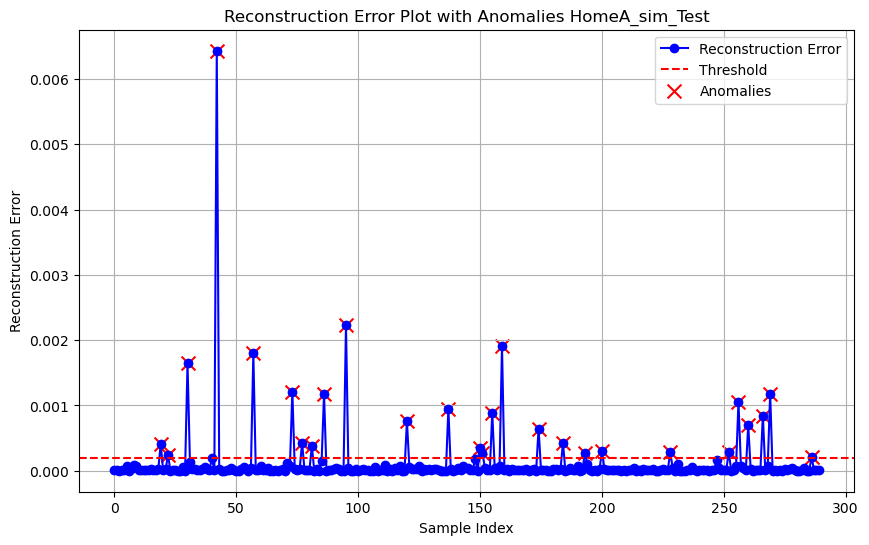

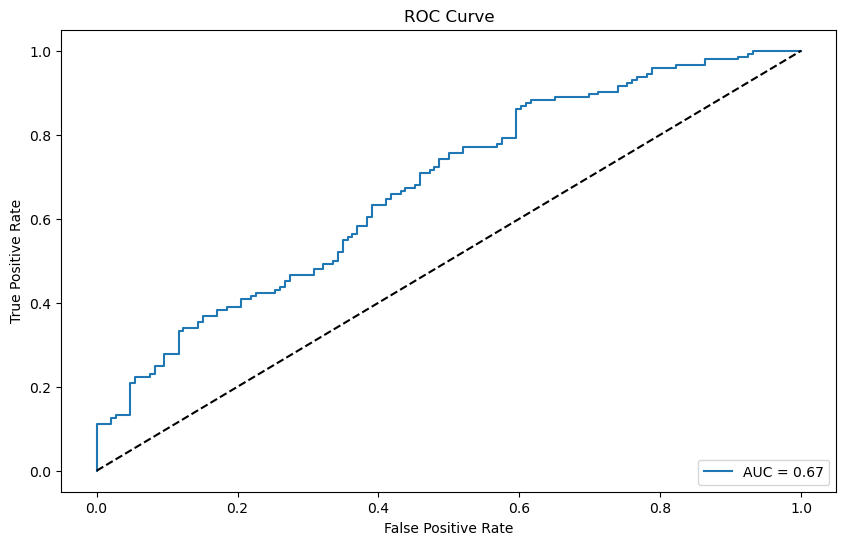

In [22]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
